In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.tail()


,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
df=df.drop(columns=["Unnamed: 0"])
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [9]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.corr(numeric_only=True)


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

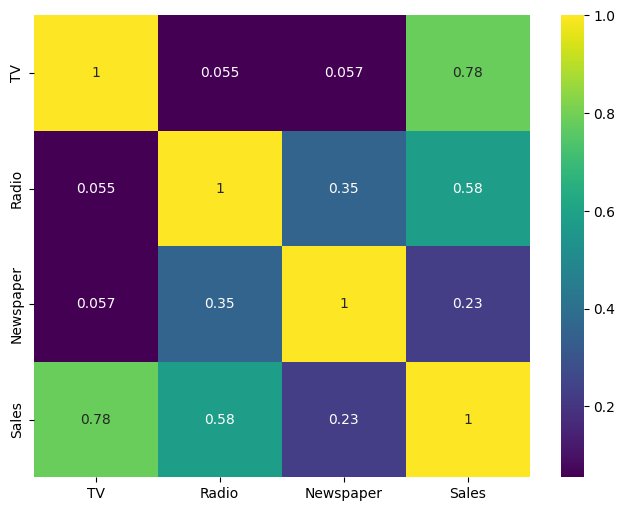

In [12]:
corr=df.corr(numeric_only=True)
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap( corr,annot=True,ax=ax,cmap='viridis')


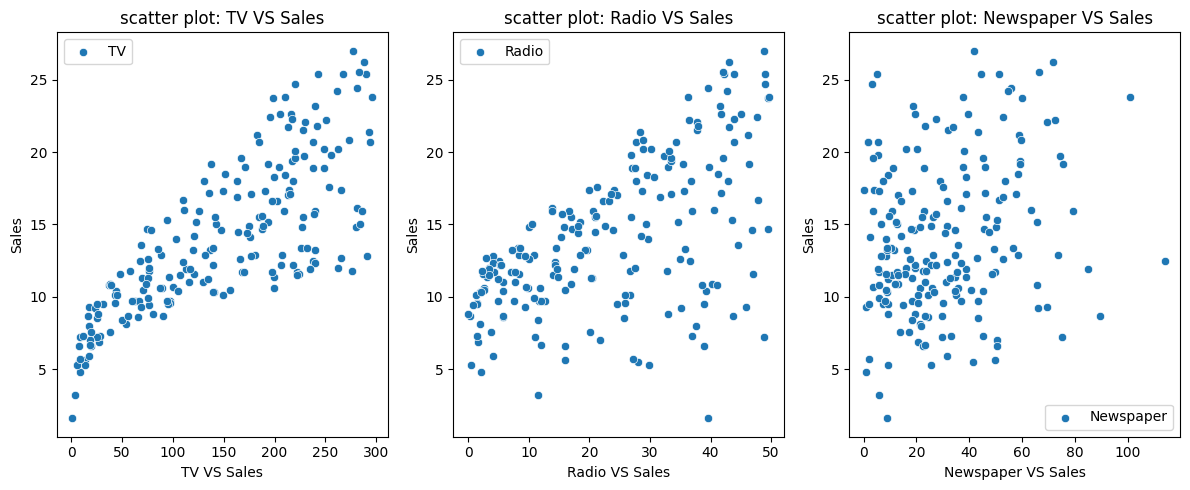

In [13]:
plt.figure(figsize=(12,5))
columns={0:"TV",1:"Radio",2:"Newspaper"}
for plot, col_name in columns.items():
    plt.subplot(1,3,plot+1)
    sns.scatterplot(x=df[col_name],y=df['Sales'], label= col_name,palette="pastel")
    plt.xlabel("{} VS Sales".format(col_name))
    plt.title("scatter plot: {} VS Sales".format(col_name))
    plt.legend()
plt.tight_layout()
plt.show()

In [25]:
X=df.drop("Sales",axis=1)
y=df["Sales"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler



In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
print("Accuracy (Linear Regression): ",model.score(X_test,y_test)*100)

Accuracy (Linear Regression):  89.9438024100912


Linear Regression
Mean Squared Error (MSE): 3.1741
Mean Absolute Error (MAE): 1.4608
Root Mean Squared Error (RMSE): 1.7816
R² Score: 0.8994
Average Cross Validation R²: 0.8595


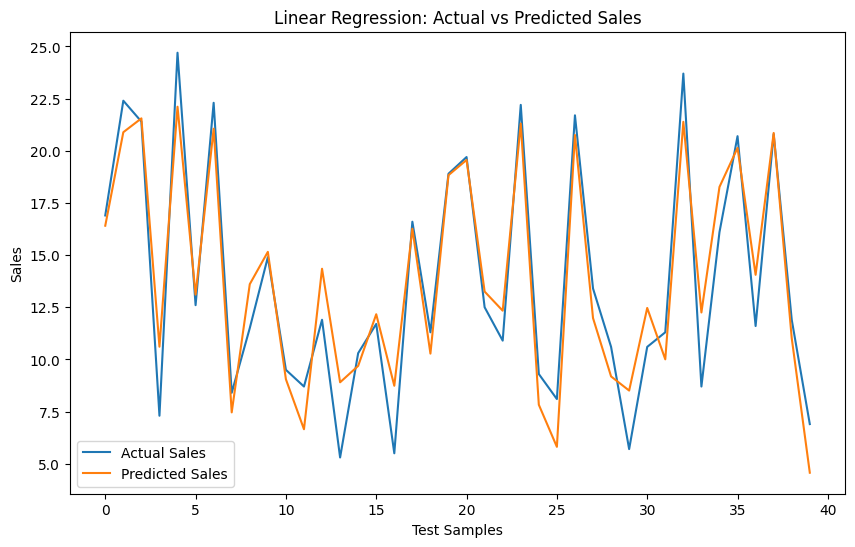

In [42]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("Linear Regression")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Average Cross Validation R²: {cv_scores.mean():.4f}")
plt.figure(figsize=(10,6))
plt.plot(np.arange(len(y_test)), y_test.values, label="Actual Sales")
plt.plot(np.arange(len(y_test)), y_pred, label="Predicted Sales")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.title("Linear Regression: Actual vs Predicted Sales")
plt.legend()
plt.show()

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
mse_rf = mean_squared_error(y_test, rf_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, rf_pred)

cv_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Random Forest Results")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)
print("Cross Validation R²:", cv_rf.mean())

Random Forest Results
MAE : 0.6207249999999989
MSE : 0.5910253749999989
RMSE: 0.7687817473119395
R² Score: 0.9812750924472915
Cross Validation R²: 0.9692199926241318


In [44]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest"
    ],
    "MAE":[
        mae,
        mae_rf
    ],
    "RMSE":[
        rmse,
        rmse_rf
    ],
    "R² Score":[
        r2,
        r2_rf
    ],
    "CV R²":[
        cv_scores.mean(),
        cv_rf.mean()
    ]
})

results

,Model,MAE,RMSE,R² Score,CV R²
0,Linear Regression,1.460757,1.781600,0.899438,0.859488
1,Random Forest,0.620725,0.768782,0.981275,0.969220


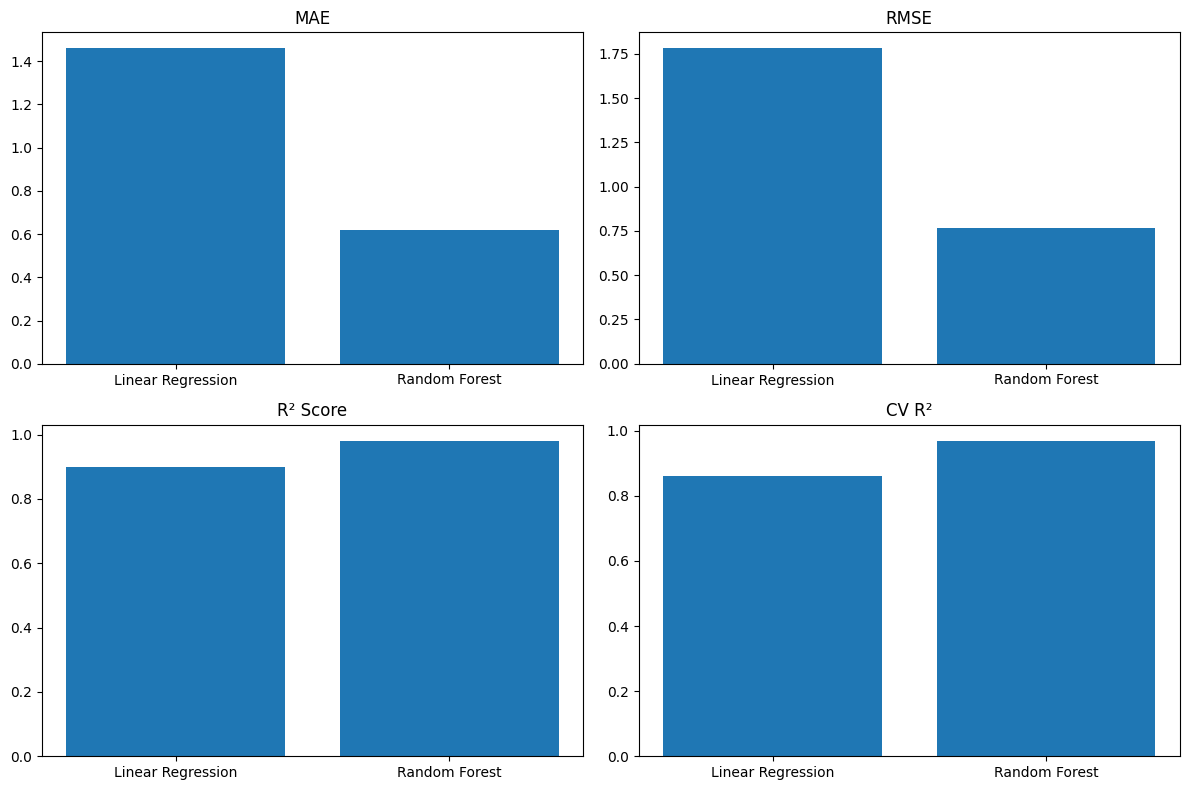

In [45]:
import matplotlib.pyplot as plt

metrics = ["MAE", "RMSE", "R² Score", "CV R²"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, metric in zip(axes.ravel(), metrics):
    ax.bar(results["Model"], results[metric])
    ax.set_title(metric)

plt.tight_layout()
plt.show()

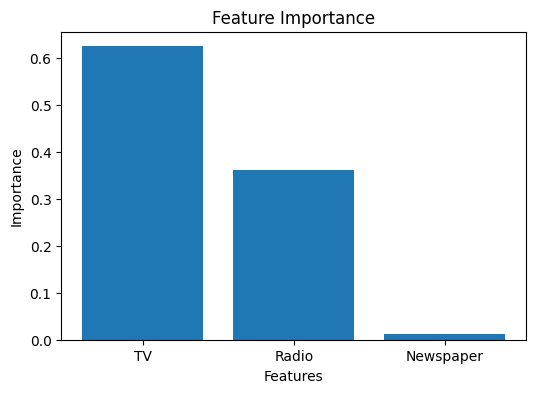

In [46]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(6,4))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [47]:
final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [48]:
import joblib

joblib.dump(final_model, "sales_prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [53]:
import numpy as np

new_data = np.array([[150,30,20]])

new_data = scaler.transform(new_data)

prediction = final_model.predict(new_data)

print("Predicted Sales:",prediction[0])

Predicted Sales: 16.679999999999986


3
